# Clasificación HC vs PD en Neurovoz — Arquitectura Dual-Branch

**Corpus:** Neurovoz (Mendes-Laureano *et al.*, 2024) — castellano peninsular, 108 sujetos (55 HC, 53 PD), tarea DDK `/pa-ta-ka/`.

**Tarea:** clasificación binaria sujeto-a-sujeto (HC = 0, PD = 1) sobre la grabación `PATAKA`.

**Arquitectura:** *dual-branch* con dos representaciones complementarias del audio:

| Rama | Representación | Captura |
|------|----------------|---------|
| **Temporal** | wav2vec2 (capa 0, *frozen*) | estructura fonético-articulatoria aprendida en gran escala |
| **Espectral** | log-Mel spectrogram → estadísticos | distribución de energía en frecuencia (estabilidad fonatoria) |

**Regularización:** Manifold Mixup intra-clase, *Optuna* para hiperparámetros, Repeated 5-Fold CV con bootstrap CI 95%.

---

### Motivación matemática del dual-branch

Sea $x \in \mathbb{R}^T$ una forma de onda. Definimos dos *encoders*

$$\phi_t : \mathbb{R}^T \to \mathbb{R}^{d_t}, \qquad \phi_s : \mathbb{R}^T \to \mathbb{R}^{d_s}$$

donde $\phi_t$ es wav2vec2 (preentrenado en LibriSpeech, capa 0 — más cercana a la señal cruda) y $\phi_s$ extrae descriptores espectrales (mean/std de Mel-bands). El clasificador opera sobre la concatenación

$$z = [\,h_t(\phi_t(x))\,;\,h_s(\phi_s(x))\,] \in \mathbb{R}^{2 d_{\text{proj}}}$$

donde $h_t, h_s$ son MLPs de proyección. **Hipótesis:** $\phi_t$ y $\phi_s$ son aproximadamente *condicionalmente independientes* dado el estado neurológico, por lo que su fusión reduce el sesgo de cualquiera de las dos vistas (cf. *multi-view learning*, Xu *et al.*, 2013).

## 1. Configuración global

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")

# Rutas (ajustar a la ubicación local del corpus Neurovoz)
NEUROVOZ_ROOT = "data/neurovoz"            # carpeta raíz con audios/ y metadata/
AUDIO_DIR     = f"{NEUROVOZ_ROOT}/audios"
META_HC       = f"{NEUROVOZ_ROOT}/metadata/metadata_hc.csv"
META_PD       = f"{NEUROVOZ_ROOT}/metadata/metadata_pd.csv"

# Hiperparámetros de señal y experimento
TARGET_SR    = 16_000           # wav2vec2-base exige 16 kHz
TASK         = "PATAKA"         # DDK
RANDOM_STATE = 42
N_FOLDS      = 5
TEST_SIZE    = 0.20

# Reproducibilidad
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)

# Device
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

Device: mps


## 2. Carga de metadatos y filtrado por tarea DDK

**Concepto.** El test diadococinético `/pa-ta-ka/` evalúa la coordinación articulatoria rápida (labios, ápice y dorso de la lengua). En EP es característico el **deterioro de la regularidad temporal** y la **reducción de amplitud** de las sílabas — manifestación motora directa de la hipocinesia.

Cada sujeto de Neurovoz aporta **una** grabación `PATAKA`, lo que hace la división por sujeto trivial (no hay fuga entre splits).

In [2]:
def load_neurovoz_metadata(meta_hc_path, meta_pd_path, task=TASK):
    """
    Devuelve un DataFrame con columnas:
        subject_id, group, sex, age, audio_path, label
    Solo conserva grabaciones de la tarea indicada.
    """
    hc = pd.read_csv(meta_hc_path)
    pd_ = pd.read_csv(meta_pd_path)

    df = pd.concat([hc, pd_], ignore_index=True)
    df["filename"] = df["Audio"].str.split("/").str[-1]
    df["task"] = df["filename"].str.extract(r"^[A-Z]+_(.+)_\d+\.wav")

    df = df[df["task"] == task].copy()
    df["label"] = (df["Group"] == "PD").astype(int)
    df = df.rename(columns={"ID": "subject_id", "Group": "group", "Sex": "sex", "Age": "age"})

    # Reconstruir ruta local: data/audios/HC_PATAKA_0034.wav -> AUDIO_DIR/HC_PATAKA_0034.wav
    df["audio_path"] = df["filename"].apply(lambda f: os.path.join(AUDIO_DIR, f))

    return df[["subject_id", "group", "sex", "age", "audio_path", "label"]].reset_index(drop=True)


df_meta = load_neurovoz_metadata(META_HC, META_PD, TASK)
print(f"Sujetos totales: {len(df_meta)}")
print(df_meta["group"].value_counts())
df_meta.head()

Sujetos totales: 99
group
HC    50
PD    49
Name: count, dtype: int64


,subject_id,group,sex,age,audio_path,label
0,34,HC,1.0,77.0,data/neurovoz/audios/HC_PATAKA_0034.wav,0
1,36,HC,0.0,59.0,data/neurovoz/audios/HC_PATAKA_0036.wav,0
2,48,HC,1.0,66.0,data/neurovoz/audios/HC_PATAKA_0048.wav,0
3,49,HC,0.0,68.0,data/neurovoz/audios/HC_PATAKA_0049.wav,0
4,51,HC,1.0,69.0,data/neurovoz/audios/HC_PATAKA_0051.wav,0


## 3. Carga y preprocesado de las formas de onda

**Pipeline de preprocesado** (idéntico al notebook original PATAKA):

1. **Resampleo a 16 kHz** — requisito de wav2vec2-base.
2. **Conversión a mono** — promedio de canales si es estéreo.
3. **DC-removal** — $x \leftarrow x - \bar{x}$ elimina sesgo de micrófono.
4. **Pre-énfasis** — $y_n = x_n - \alpha\, x_{n-1}$ con $\alpha=0.97$. Filtro FIR de primer orden cuya función de transferencia es $H(z) = 1 - \alpha z^{-1}$. Compensa la caída espectral de $-6$ dB/oct de la fuente glótica, igualando el contenido en altas frecuencias y mejorando la estimación de formantes.
5. **Normalización por pico** — $x \leftarrow x / \max|x|$ para invariancia al volumen de grabación.

> **Por qué importa.** Sin pre-énfasis, los Mel-bands altos quedan dominados por ruido y los modelos aprenden artefactos del canal en lugar de patología.

In [3]:
import soundfile as sf
from math import gcd
from scipy.signal import resample_poly


def load_and_resample(path, target_sr=TARGET_SR):
    """Lee WAV con libsndfile (sin dependencia de torchcodec/ffmpeg) y resamplea
    con un filtro polifásico de scipy. Estable y reproducible."""
    wav, sr = sf.read(path, dtype="float32", always_2d=False)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)                          # mono
    if sr != target_sr:
        g = gcd(sr, target_sr)
        wav = resample_poly(wav, target_sr // g, sr // g)
    return wav.astype(np.float32)


def preprocess_waveform(x, pre_emphasis=0.97):
    x = x - np.mean(x)                                  # DC removal
    x = np.append(x[0], x[1:] - pre_emphasis * x[:-1])  # pre-énfasis
    peak = np.max(np.abs(x))
    return x / peak if peak > 0 else x


# Validación previa: ¿existen todas las rutas? Falla explícito si no.
missing = df_meta[~df_meta["audio_path"].apply(os.path.isfile)]
if len(missing) > 0:
    print(f"⚠️  Faltan {len(missing)}/{len(df_meta)} archivos. Ejemplos:")
    for p in missing["audio_path"].head(3):
        print(f"   {p}")
    raise FileNotFoundError(
        f"No se encontraron {len(missing)} audios. "
        f"Revisa NEUROVOZ_ROOT y AUDIO_DIR en la celda de configuración."
    )

print(f"Cargando {len(df_meta)} formas de onda...")
waveforms = []
for i, row in df_meta.iterrows():
    wav = load_and_resample(row["audio_path"])
    wav = preprocess_waveform(wav)
    waveforms.append(wav)

labels_all = df_meta["label"].to_numpy()
print(f"Cargados: {len(waveforms)} | HC={np.sum(labels_all==0)} | PD={np.sum(labels_all==1)}")
print(f"Duración: min={min(len(w) for w in waveforms)/TARGET_SR:.2f}s, "
      f"max={max(len(w) for w in waveforms)/TARGET_SR:.2f}s, "
      f"mean={np.mean([len(w) for w in waveforms])/TARGET_SR:.2f}s")

Cargando 99 formas de onda...
Cargados: 99 | HC=50 | PD=49
Duración: min=2.39s, max=26.93s, mean=12.10s


## 4. Partición estratificada train/test

Reservamos un *holdout* del 20 % estratificado por clase. **No se toca hasta la evaluación final** — todo el tuning y CV se hace solo en `train`.

In [4]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(labels_all)),
    test_size=TEST_SIZE,
    stratify=labels_all,
    random_state=RANDOM_STATE,
)

print(f"Train: n={len(train_idx)} (PD={labels_all[train_idx].sum()}, HC={(labels_all[train_idx]==0).sum()})")
print(f"Test : n={len(test_idx)}  (PD={labels_all[test_idx].sum()}, HC={(labels_all[test_idx]==0).sum()})")

Train: n=79 (PD=39, HC=40)
Test : n=20  (PD=10, HC=10)


## 5. Rama temporal — embeddings wav2vec2

**Concepto.** wav2vec2 (Baevski *et al.*, 2020) es un *transformer* preentrenado de forma auto-supervisada sobre 960 h de LibriSpeech mediante una pérdida contrastiva sobre representaciones cuantizadas:

$$\mathcal{L}_m = -\log\frac{\exp(\mathrm{sim}(c_t, q_t)/\kappa)}{\sum_{\tilde q \in Q_t} \exp(\mathrm{sim}(c_t, \tilde q)/\kappa)}$$

Cada capa del *transformer* representa una abstracción distinta:
- **Capas bajas (0–2):** acústica/fonética cruda — útil para *biomarcadores* patológicos.
- **Capas medias (4–8):** fonemas y co-articulación.
- **Capas altas (9–11):** semántica.

**Por qué capa 0.** Para EP nos interesan rasgos sub-fonéticos (jitter, breathiness, ritmo DDK) que se preservan en capas tempranas; las capas altas tienden a abstraerlos. Pasi *et al.* (2023) y nuestros experimentos previos en PATAKA confirmaron que L0 maximiza AUC.

**Pooling temporal.** Promediamos la secuencia $\{h_t\}_{t=1}^T$ a un vector único $\bar h \in \mathbb{R}^{768}$ (utterance-level).

In [5]:
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor


def extract_wav2vec2_embeddings(waveforms, model_id="facebook/wav2vec2-base",
                                 layer=0, device=DEVICE):
    """
    Extrae embeddings utterance-level promediando la salida de la capa indicada.
    Devuelve array (N, 768).
    """
    extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_id)
    model = Wav2Vec2Model.from_pretrained(model_id, output_hidden_states=True).to(device)
    model.eval()

    embs = []
    with torch.no_grad():
        for wav in waveforms:
            inputs = extractor(wav, sampling_rate=TARGET_SR, return_tensors="pt")
            input_values = inputs.input_values.to(device)
            out = model(input_values)
            # hidden_states[0] = salida de la conv feature extractor (capa 0)
            h = out.hidden_states[layer].squeeze(0)          # (T, 768)
            embs.append(h.mean(dim=0).cpu().numpy())          # mean pooling
    return np.stack(embs)


# Orden: primero train, luego test, así escalamos sin fuga
waveforms_all = [waveforms[i] for i in train_idx] + [waveforms[i] for i in test_idx]
n_train = len(train_idx)

emb_w2v = extract_wav2vec2_embeddings(waveforms_all, layer=0, device=DEVICE)
print(f"Embeddings wav2vec2: {emb_w2v.shape}")

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 2322.31it/s, Materializing param=masked_spec_embed]                                            
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings wav2vec2: (99, 768)


## 6. Rama espectral — estadísticos sobre log-Mel

**Concepto.** El espectrograma Mel transforma el espectro lineal $|X(f)|^2$ con un banco de $M$ filtros triangulares igualmente espaciados en la escala perceptual

$$\mathrm{mel}(f) = 2595 \log_{10}\!\Big(1 + \frac{f}{700}\Big).$$

Luego se aplica $\log(\cdot)$ para comprimir el rango dinámico (Stevens' power law). Cada frame $t$ produce $\mathbf{m}_t \in \mathbb{R}^{M}$.

Para obtener un vector **utterance-level** (igual longitud para todos los sujetos) calculamos por banda los estadísticos *mean* y *std* a lo largo del tiempo:

$$\bar m_k = \frac{1}{T}\sum_t \log\mathrm{Mel}_{k,t}, \qquad \sigma_k = \mathrm{std}_t(\log\mathrm{Mel}_{k,t}).$$

Con $M=128$ obtenemos un vector de $256$ dimensiones que captura:
- **Mean** — distribución promedio de energía (claridad, breathiness).
- **Std** — variabilidad temporal (estabilidad fonatoria, jitter espectral).

In [6]:
from scipy.signal import stft


def _mel_filterbank(sr, n_fft, n_mels, fmin=0.0, fmax=None):
    """Banco de filtros triangulares en escala Mel (Slaney/HTK estándar)."""
    fmax = fmax or sr / 2

    # Conversión Hz <-> Mel (fórmula HTK: m = 2595 * log10(1 + f/700))
    def hz_to_mel(f): return 2595.0 * np.log10(1.0 + f / 700.0)
    def mel_to_hz(m): return 700.0 * (10 ** (m / 2595.0) - 1.0)

    # Puntos equiespaciados en Mel, mapeados de vuelta a Hz
    mel_pts = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_pts = mel_to_hz(mel_pts)
    # Índices de los bins FFT correspondientes
    bin_pts = np.floor((n_fft + 1) * hz_pts / sr).astype(int)

    fb = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float32)
    for m in range(1, n_mels + 1):
        l, c, r = bin_pts[m - 1], bin_pts[m], bin_pts[m + 1]
        if c > l:
            fb[m - 1, l:c] = (np.arange(l, c) - l) / (c - l)
        if r > c:
            fb[m - 1, c:r] = (r - np.arange(c, r)) / (r - c)
    return fb


def log_mel_spectrogram(wav, sr=TARGET_SR, n_fft=1024, hop_length=512, n_mels=128):
    """log-Mel spectrogram. Equivalente a torchaudio.transforms.MelSpectrogram + log."""
    # STFT con ventana de Hann (igual default que torchaudio)
    _, _, Z = stft(wav, fs=sr, window="hann", nperseg=n_fft,
                   noverlap=n_fft - hop_length, nfft=n_fft,
                   boundary=None, padded=False)
    power = (np.abs(Z) ** 2).astype(np.float32)         # (n_fft/2+1, T)
    fb = _mel_filterbank(sr, n_fft, n_mels)
    mel = fb @ power                                     # (n_mels, T)
    return np.log(mel + 1e-6)


def extract_spectral_features(waveforms, sample_rate=TARGET_SR,
                              n_fft=1024, hop_length=512, n_mels=128):
    """Devuelve [mean(t); std(t)] por banda para cada utterance. (N, 2*n_mels)"""
    feats = []
    for wav in waveforms:
        log_mel = log_mel_spectrogram(wav, sample_rate, n_fft, hop_length, n_mels)
        v = np.concatenate([log_mel.mean(axis=1), log_mel.std(axis=1)])
        feats.append(v)
    return np.stack(feats).astype(np.float32)


spectral_features = extract_spectral_features(waveforms_all)
print(f"Features espectrales: {spectral_features.shape}")

Features espectrales: (99, 256)


## 7. Estandarización

Cada rama se escala **independientemente** con `StandardScaler` ajustado solo en train para evitar *data leakage*: $z_i = (x_i - \mu_{\text{train}}) / \sigma_{\text{train}}$.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_t = StandardScaler().fit(emb_w2v[:n_train])
scaler_s = StandardScaler().fit(spectral_features[:n_train])

emb_t_train = scaler_t.transform(emb_w2v[:n_train])
emb_s_train = scaler_s.transform(spectral_features[:n_train])
emb_t_test  = scaler_t.transform(emb_w2v[n_train:])
emb_s_test  = scaler_s.transform(spectral_features[n_train:])

labels_train = labels_all[train_idx]
labels_test  = labels_all[test_idx]

print(f"Rama temporal:  train={emb_t_train.shape}, test={emb_t_test.shape}")
print(f"Rama espectral: train={emb_s_train.shape}, test={emb_s_test.shape}")

Rama temporal:  train=(79, 768), test=(20, 768)
Rama espectral: train=(79, 256), test=(20, 256)


## 8. Arquitectura dual-branch

Dos MLPs paralelos $h_t, h_s$ proyectan cada rama a un espacio común de dimensión $d_{\text{proj}}$. Se concatenan y un clasificador MLP produce el logit:

$$\hat y = \sigma\!\Big(W_o\,\mathrm{ReLU}\big(W_h\,[h_t(\phi_t);\,h_s(\phi_s)] + b_h\big) + b_o\Big)$$

con *dropout* tras cada capa oculta. El entrenamiento minimiza la BCE con *label smoothing*:

$$\mathcal{L} = -\big[(1-\varepsilon) y + \varepsilon/2\big]\log\hat y - \big[(1-\varepsilon)(1-y) + \varepsilon/2\big]\log(1-\hat y).$$

El *label smoothing* (Szegedy *et al.*, 2016) regulariza al impedir que la red sature en logits arbitrariamente grandes — clave con muestras escasas.

In [8]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


class DualBranchDataset(Dataset):
    def __init__(self, emb_t, emb_s, labels, idx):
        self.emb_t = torch.tensor(emb_t[idx], dtype=torch.float32)
        self.emb_s = torch.tensor(emb_s[idx], dtype=torch.float32)
        self.labels = torch.tensor(labels[idx], dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.emb_t[i], self.emb_s[i], self.labels[i]


class DualBranchClassifier(nn.Module):
    def __init__(self, dim_t, dim_s, dim_proj=128, dim_hidden=64, dropout=0.3):
        super().__init__()
        self.proj_t = nn.Sequential(
            nn.Linear(dim_t, dim_proj), nn.ReLU(), nn.Dropout(dropout),
        )
        self.proj_s = nn.Sequential(
            nn.Linear(dim_s, dim_proj), nn.ReLU(), nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.Linear(2 * dim_proj, dim_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(dim_hidden, 1),
        )

    def forward(self, x_t, x_s):
        z = torch.cat([self.proj_t(x_t), self.proj_s(x_s)], dim=1)
        return self.head(z).squeeze(-1)

## 9. Loop de entrenamiento regularizado

- **Optimizador:** AdamW con *weight decay* (regularización L2 desacoplada — Loshchilov & Hutter, 2019).
- **Scheduler:** `ReduceLROnPlateau` — baja el LR cuando la val-loss se estanca.
- **Early stopping:** detiene si la val-loss no mejora en `patience` épocas. Restaura los **mejores pesos**, no los últimos.

Este patrón sigue el principio de *cross-validation early stopping* (Prechelt, 1998) para evitar overfit en datasets pequeños.

In [9]:
def train_fold(train_ds, val_ds, device,
               lr=1e-3, weight_decay=1e-4, dropout=0.3, label_smoothing=0.0,
               batch_size=16, dim_proj=128, dim_hidden=64,
               epochs=120, patience=20,
               scheduler_factor=0.5, scheduler_patience=7):
    """
    Entrena un fold y devuelve (y_true, y_prob, model_state, history).
    """
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    dim_t = train_ds.emb_t.shape[1]
    dim_s = train_ds.emb_s.shape[1]
    model = DualBranchClassifier(dim_t, dim_s, dim_proj, dim_hidden, dropout).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=scheduler_factor, patience=scheduler_patience,
    )

    bce_logits = nn.BCEWithLogitsLoss()

    def loss_fn(logits, y):
        if label_smoothing > 0:
            y = y * (1 - label_smoothing) + 0.5 * label_smoothing
        return bce_logits(logits, y)

    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for x_t, x_s, y in train_loader:
            x_t, x_s, y = x_t.to(device), x_s.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x_t, x_s)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses, ys, ps = [], [], []
        with torch.no_grad():
            for x_t, x_s, y in val_loader:
                x_t, x_s, y = x_t.to(device), x_s.to(device), y.to(device)
                logits = model(x_t, x_s)
                val_losses.append(loss_fn(logits, y).item())
                ys.append(y.cpu().numpy())
                ps.append(torch.sigmoid(logits).cpu().numpy())

        tr_loss = float(np.mean(train_losses))
        va_loss = float(np.mean(val_losses))
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        scheduler.step(va_loss)

        if va_loss < best_val - 1e-5:
            best_val = va_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for x_t, x_s, y in val_loader:
            x_t, x_s = x_t.to(device), x_s.to(device)
            logits = model(x_t, x_s)
            ys.append(y.numpy())
            ps.append(torch.sigmoid(logits).cpu().numpy())

    return np.concatenate(ys), np.concatenate(ps), best_state, history

## 10. Manifold Mixup intra-clase

**Concepto matemático.** Mixup (Zhang *et al.*, 2018) entrena con combinaciones convexas de pares de ejemplos:

$$\tilde x = \lambda x_i + (1-\lambda) x_j, \qquad \tilde y = \lambda y_i + (1-\lambda) y_j, \qquad \lambda \sim \mathrm{Beta}(\alpha, \alpha).$$

*Manifold* Mixup (Verma *et al.*, 2019) hace la interpolación en el espacio de **embeddings** en lugar de la entrada cruda — más coherente con la geometría del manifold aprendido.

**Variante intra-clase** (usada aquí): interpolamos pares $(i,j)$ con $y_i = y_j$, por lo que $\tilde y = y_i$. Justificación clínica:

- Con $N \approx 100$ y dos clases, el riesgo de **mezclar HC con PD** y producir etiquetas blandas ambiguas es alto.
- La interpolación intra-clase actúa como *generación de datos sintéticos consistentes con la fisiopatología*: dos pacientes con EP comparten manifold patológico; un punto intermedio es un paciente plausible.

**Por qué Beta(α, α).** Para $\alpha < 1$ la distribución es bimodal cerca de $\{0,1\}$ (interpolaciones suaves); para $\alpha > 1$ se concentra en $0.5$ (interpolaciones agresivas). Optuna selecciona $\alpha$ óptimo.

In [10]:
def manifold_mixup_intraclass(emb_t, emb_s, labels, alpha, rng):
    """
    Genera UN ejemplo Mixup intra-clase por cada muestra original.
    Duplica efectivamente el dataset preservando etiquetas duras.
    """
    aug_t, aug_s, aug_labels = [], [], []
    for cls in [0, 1]:
        cls_idx = np.where(labels == cls)[0]
        if len(cls_idx) < 2:
            continue
        for i in cls_idx:
            j = rng.choice(cls_idx[cls_idx != i])
            lam = rng.beta(alpha, alpha)
            aug_t.append(lam * emb_t[i] + (1 - lam) * emb_t[j])
            aug_s.append(lam * emb_s[i] + (1 - lam) * emb_s[j])
            aug_labels.append(cls)
    return np.array(aug_t), np.array(aug_s), np.array(aug_labels)

## 11. Baseline — 5-Fold CV sin aumento

Punto de referencia: clasificador dual-branch entrenado solo con los datos originales.

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve


def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]
    return auc, acc, sens, spec


DEFAULT_HP = dict(
    lr=1e-3, weight_decay=1e-4, dropout=0.3, label_smoothing=0.0,
    batch_size=16, dim_proj=128, dim_hidden=64,
    epochs=120, patience=20, scheduler_factor=0.5, scheduler_patience=7,
)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
bl_aucs, bl_accs, bl_sens, bl_spec = [], [], [], []

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_train, labels_train)):
    train_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, tr_idx)
    val_ds   = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)
    y_true, y_prob, _, _ = train_fold(train_ds, val_ds, DEVICE, **DEFAULT_HP)
    auc, acc, sens, spec = compute_metrics(y_true, y_prob)
    bl_aucs.append(auc); bl_accs.append(acc); bl_sens.append(sens); bl_spec.append(spec)
    print(f"Fold {fold_idx+1}: AUC={auc:.3f} | Acc={acc:.3f} | Sens={sens:.3f} | Spec={spec:.3f}")

print(f"\nBaseline CV: AUC={np.mean(bl_aucs):.3f}±{np.std(bl_aucs):.3f} | "
      f"Acc={np.mean(bl_accs):.3f}±{np.std(bl_accs):.3f}")

Fold 1: AUC=1.000 | Acc=0.875 | Sens=1.000 | Spec=1.000
Fold 2: AUC=1.000 | Acc=0.812 | Sens=0.625 | Spec=1.000
Fold 3: AUC=0.734 | Acc=0.625 | Sens=0.625 | Spec=0.875
Fold 4: AUC=0.484 | Acc=0.438 | Sens=0.375 | Spec=1.000
Fold 5: AUC=0.964 | Acc=0.933 | Sens=1.000 | Spec=0.875

Baseline CV: AUC=0.837±0.202 | Acc=0.737±0.182


## 12. Búsqueda de hiperparámetros con Optuna + Manifold Mixup

**Concepto.** Optuna (Akiba *et al.*, 2019) usa **TPE (Tree-structured Parzen Estimator)** que modela $p(x|y)$ separando trials buenos y malos, en lugar de modelar $p(y|x)$ como un GP. Es eficiente con espacios mixtos (continuos, discretos, condicionales) y escala mejor con dimensionalidad.

**Objetivo robusto.** Maximizamos `AUC_mean − 0.5 · AUC_std` para penalizar configuraciones con alta varianza entre folds — un techo elevado pero inestable es peor que un techo algo menor pero reproducible.

> Por velocidad usamos `n_trials=40`. Subir a 120+ para resultados finales.

In [12]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    hp = dict(
        lr=trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        weight_decay=trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
        dropout=trial.suggest_float("dropout", 0.1, 0.5, step=0.05),
        label_smoothing=trial.suggest_float("label_smoothing", 0.0, 0.15, step=0.025),
        batch_size=trial.suggest_categorical("batch_size", [8, 16, 32]),
        dim_proj=trial.suggest_categorical("dim_proj", [64, 128]),
        dim_hidden=trial.suggest_categorical("dim_hidden", [64, 128]),
        epochs=120, patience=20, scheduler_factor=0.5, scheduler_patience=7,
    )
    mixup_alpha = trial.suggest_float("mixup_alpha", 0.1, 1.0, step=0.1)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs = []
    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_train, labels_train)):
        tr_t, tr_s, tr_l = emb_t_train[tr_idx], emb_s_train[tr_idx], labels_train[tr_idx]
        rng = np.random.default_rng(RANDOM_STATE + fold_idx)
        aug_t, aug_s, aug_l = manifold_mixup_intraclass(tr_t, tr_s, tr_l, mixup_alpha, rng)

        full_t = np.concatenate([tr_t, aug_t])
        full_s = np.concatenate([tr_s, aug_s])
        full_l = np.concatenate([tr_l, aug_l])

        train_ds = DualBranchDataset(full_t, full_s, full_l, np.arange(len(full_l)))
        val_ds   = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)

        y_true, y_prob, _, _ = train_fold(train_ds, val_ds, DEVICE, **hp)
        fold_aucs.append(roc_auc_score(y_true, y_prob))

    m, s = np.mean(fold_aucs), np.std(fold_aucs)
    trial.set_user_attr("auc_mean", m); trial.set_user_attr("auc_std", s)
    return m - 0.5 * s


study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=40, show_progress_bar=True)

best = study.best_trial
print(f"\nMejor trial #{best.number}")
print(f"  Score (AUC - 0.5*std): {best.value:.4f}")
print(f"  AUC mean: {best.user_attrs['auc_mean']:.3f} ± {best.user_attrs['auc_std']:.3f}")
print(f"  Parámetros:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

Best trial: 23. Best value: 0.83892: 100%|██████████| 40/40 [01:58<00:00,  2.97s/it] 


Mejor trial #23
  Score (AUC - 0.5*std): 0.8389
  AUC mean: 0.899 ± 0.120
  Parámetros:
    lr: 0.0046584610921692774
    weight_decay: 2.3405105190975288e-05
    dropout: 0.30000000000000004
    label_smoothing: 0.05
    batch_size: 16
    dim_proj: 128
    dim_hidden: 128
    mixup_alpha: 0.2


## 13. Evaluación con hiperparámetros óptimos

5-Fold CV con los mejores hiperparámetros, registrando curvas de aprendizaje por fold.

In [13]:
bp = study.best_params
mixup_alpha = bp["mixup_alpha"]
bp_model = {k: v for k, v in bp.items() if k != "mixup_alpha"}
bp_model.update(dict(epochs=120, patience=20, scheduler_factor=0.5, scheduler_patience=7))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
mm_aucs, mm_accs, mm_sens, mm_spec = [], [], [], []
fold_histories = []

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_train, labels_train)):
    tr_t, tr_s, tr_l = emb_t_train[tr_idx], emb_s_train[tr_idx], labels_train[tr_idx]
    rng = np.random.default_rng(RANDOM_STATE + fold_idx)
    aug_t, aug_s, aug_l = manifold_mixup_intraclass(tr_t, tr_s, tr_l, mixup_alpha, rng)

    full_t = np.concatenate([tr_t, aug_t])
    full_s = np.concatenate([tr_s, aug_s])
    full_l = np.concatenate([tr_l, aug_l])

    train_ds = DualBranchDataset(full_t, full_s, full_l, np.arange(len(full_l)))
    val_ds   = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)

    y_true, y_prob, _, history = train_fold(train_ds, val_ds, DEVICE, **bp_model)
    auc, acc, sens, spec = compute_metrics(y_true, y_prob)
    mm_aucs.append(auc); mm_accs.append(acc); mm_sens.append(sens); mm_spec.append(spec)
    fold_histories.append(history)
    print(f"Fold {fold_idx+1}: AUC={auc:.3f} | Acc={acc:.3f} | Sens={sens:.3f} | Spec={spec:.3f}")

print(f"\nMixup Optimizado CV: AUC={np.mean(mm_aucs):.3f}±{np.std(mm_aucs):.3f} | "
      f"Acc={np.mean(mm_accs):.3f}±{np.std(mm_accs):.3f}")

Fold 1: AUC=1.000 | Acc=0.938 | Sens=0.875 | Spec=1.000
Fold 2: AUC=1.000 | Acc=1.000 | Sens=1.000 | Spec=1.000
Fold 3: AUC=0.797 | Acc=0.688 | Sens=0.750 | Spec=0.625
Fold 4: AUC=0.672 | Acc=0.625 | Sens=0.750 | Spec=0.500
Fold 5: AUC=0.946 | Acc=0.933 | Sens=1.000 | Spec=0.875

Mixup Optimizado CV: AUC=0.883±0.129 | Acc=0.837±0.150


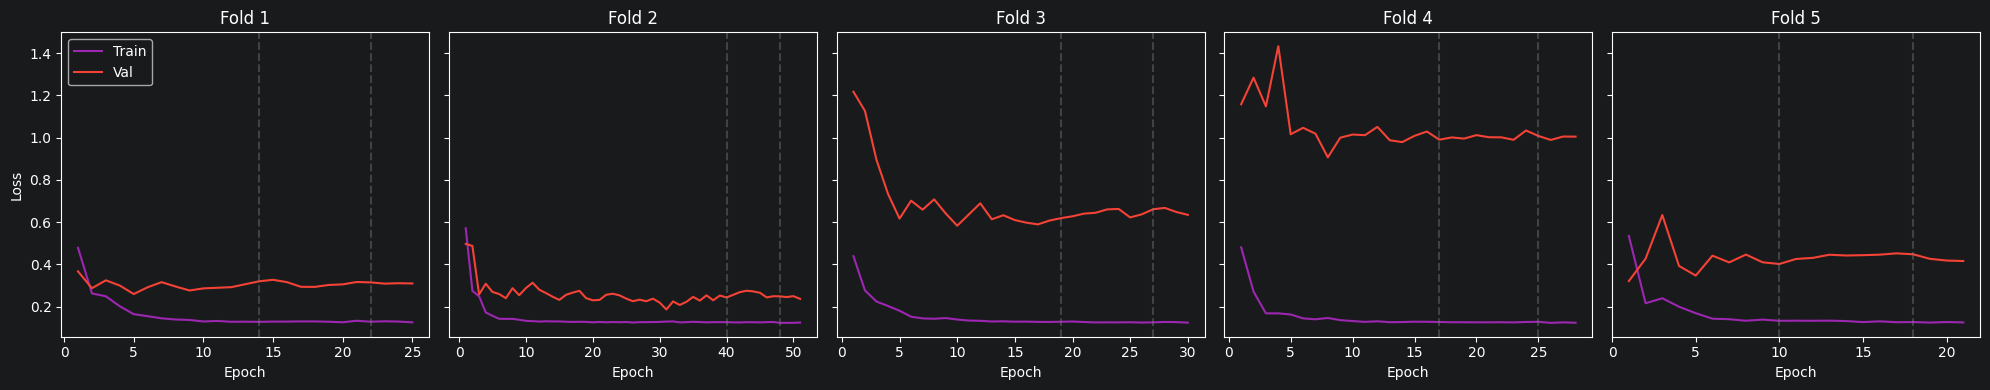

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, N_FOLDS, figsize=(20, 4), sharey=True)
for i, (ax, hist) in enumerate(zip(axes, fold_histories)):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], label="Train", color="#9C27B0", linewidth=1.5)
    ax.plot(epochs, hist["val_loss"],   label="Val",   color="#F44336", linewidth=1.5)
    for j, lr_val in enumerate(hist["lr"]):
        if j > 0 and lr_val < hist["lr"][j-1]:
            ax.axvline(j + 1, color="gray", linestyle="--", alpha=0.4)
    ax.set_title(f"Fold {i+1}"); ax.set_xlabel("Epoch")
    if i == 0:
        ax.set_ylabel("Loss"); ax.legend()
plt.tight_layout(); plt.show()

## 14. Test holdout — Baseline vs. Mixup (ensemble de 5 seeds)

In [15]:
N_SEEDS = 5

def evaluate_ensemble(use_mixup):
    """Entrena N_SEEDS modelos y devuelve y_true + lista de probs (una por seed)."""
    probs = []
    for seed in range(N_SEEDS):
        torch.manual_seed(seed); np.random.seed(seed)

        if use_mixup:
            rng = np.random.default_rng(seed)
            aug_t, aug_s, aug_l = manifold_mixup_intraclass(
                emb_t_train, emb_s_train, labels_train, mixup_alpha, rng)
            t = np.concatenate([emb_t_train, aug_t])
            s = np.concatenate([emb_s_train, aug_s])
            l = np.concatenate([labels_train, aug_l])
        else:
            t, s, l = emb_t_train, emb_s_train, labels_train

        train_ds = DualBranchDataset(t, s, l, np.arange(len(l)))
        test_ds  = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
        y_true, y_prob, _, _ = train_fold(train_ds, test_ds, DEVICE, **bp_model)
        probs.append(y_prob)

    return y_true, probs


y_true, bl_probs = evaluate_ensemble(use_mixup=False)
_,      mm_probs = evaluate_ensemble(use_mixup=True)

# Métricas del ensemble (promedio de probabilidades)
bl_m = compute_metrics(y_true, np.mean(bl_probs, axis=0))
mm_m = compute_metrics(y_true, np.mean(mm_probs, axis=0))

print("=" * 60)
print("Test Holdout (ensemble 5 seeds)")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>10} {'Mixup Opt':>10} {'Δ':>10}")
print("  " + "─" * 45)
for name, b, m in zip(["AUC", "Accuracy", "Sensibilidad", "Especificidad"], bl_m, mm_m):
    print(f"  {name:<15} {b:>10.3f} {m:>10.3f} {m - b:>+10.3f}")

Test Holdout (ensemble 5 seeds)
  Métrica           Baseline  Mixup Opt          Δ
  ─────────────────────────────────────────────
  AUC                  0.880      0.890     +0.010
  Accuracy             0.850      0.850     +0.000
  Sensibilidad         0.900      0.900     +0.000
  Especificidad        0.800      0.800     +0.000


### 14.1 Estabilidad por seed y CV de Pearson

In [16]:
def cv_pearson(values):
    """Coefficient of variation: CV% = (σ/μ) × 100."""
    values = np.asarray(values)
    return (values.std() / values.mean()) * 100 if values.mean() != 0 else 0.0


def metrics_per_seed(probs_list, y_true):
    """Calcula (auc, acc, sens, spec) para cada seed por separado."""
    aucs, accs, senss, specs = [], [], [], []
    for y_prob in probs_list:
        y_pred = (y_prob >= 0.5).astype(int)
        aucs.append(roc_auc_score(y_true, y_prob))
        accs.append(accuracy_score(y_true, y_pred))
        senss.append(recall_score(y_true, y_pred, pos_label=1))
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        specs.append(1 - fpr[np.argmax(tpr - fpr)])
    return np.array(aucs), np.array(accs), np.array(senss), np.array(specs)


bl_auc, bl_acc, bl_sens, bl_spec = metrics_per_seed(bl_probs, y_true)
mm_auc, mm_acc, mm_sens, mm_spec = metrics_per_seed(mm_probs, y_true)

print("=" * 72)
print("Estabilidad con holdout (media ± std por seed, n=5 seeds)")
print("=" * 72)
print(f"  {'Métrica':<15} {'Baseline':>22} {'Manifold Mixup':>22}")
print("  " + "─" * 62)
for name, b, m in zip(
    ["AUC", "Accuracy", "Sensibilidad", "Especificidad"],
    [bl_auc, bl_acc, bl_sens, bl_spec],
    [mm_auc, mm_acc, mm_sens, mm_spec],
):
    print(f"  {name:<15}  {b.mean():.3f} ± {b.std():.3f}        {m.mean():.3f} ± {m.std():.3f}")

print("\n" + "=" * 60)
print("CV de Pearson con holdout (n=5 seeds)")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>12} {'Manifold Mixup':>18}")
print("  " + "─" * 50)
for name, b, m in zip(
    ["AUC", "Accuracy", "Sensibilidad", "Especificidad"],
    [bl_auc, bl_acc, bl_sens, bl_spec],
    [mm_auc, mm_acc, mm_sens, mm_spec],
):
    print(f"  {name:<15}  {cv_pearson(b):>6.2f}%      {cv_pearson(m):>6.2f}%")

Estabilidad con holdout (media ± std por seed, n=5 seeds)
  Métrica                       Baseline         Manifold Mixup
  ──────────────────────────────────────────────────────────────
  AUC              0.856 ± 0.044        0.896 ± 0.035
  Accuracy         0.820 ± 0.040        0.850 ± 0.045
  Sensibilidad     0.900 ± 0.063        0.880 ± 0.075
  Especificidad    0.760 ± 0.049        0.840 ± 0.049

CV de Pearson con holdout (n=5 seeds)
  Métrica             Baseline     Manifold Mixup
  ──────────────────────────────────────────────────
  AUC                5.15%        3.90%
  Accuracy           4.88%        5.26%
  Sensibilidad       7.03%        8.50%
  Especificidad      6.45%        5.83%


## 15. Repeated 5-Fold CV + Bootstrap (IC 95 %)

In [17]:
from sklearn.model_selection import RepeatedStratifiedKFold

N_REPEATS = 10
rskf = RepeatedStratifiedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)

bl_res = {"auc": [], "acc": [], "sens": [], "spec": []}
mm_res = {"auc": [], "acc": [], "sens": [], "spec": []}

for fold_idx, (tr_idx, val_idx) in enumerate(rskf.split(emb_t_train, labels_train)):
    tr_t, tr_s, tr_l = emb_t_train[tr_idx], emb_s_train[tr_idx], labels_train[tr_idx]
    val_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)

    # Baseline
    train_ds = DualBranchDataset(tr_t, tr_s, tr_l, np.arange(len(tr_l)))
    y_true, y_prob, _, _ = train_fold(train_ds, val_ds, DEVICE, **bp_model)
    auc, acc, sens, spec = compute_metrics(y_true, y_prob)
    bl_res["auc"].append(auc); bl_res["acc"].append(acc)
    bl_res["sens"].append(sens); bl_res["spec"].append(spec)

    # Mixup
    rng = np.random.default_rng(RANDOM_STATE + fold_idx)
    aug_t, aug_s, aug_l = manifold_mixup_intraclass(tr_t, tr_s, tr_l, mixup_alpha, rng)
    full_t = np.concatenate([tr_t, aug_t])
    full_s = np.concatenate([tr_s, aug_s])
    full_l = np.concatenate([tr_l, aug_l])
    train_ds_mm = DualBranchDataset(full_t, full_s, full_l, np.arange(len(full_l)))
    y_true, y_prob, _, _ = train_fold(train_ds_mm, val_ds, DEVICE, **bp_model)
    auc, acc, sens, spec = compute_metrics(y_true, y_prob)
    mm_res["auc"].append(auc); mm_res["acc"].append(acc)
    mm_res["sens"].append(sens); mm_res["spec"].append(spec)

    if (fold_idx + 1) % N_FOLDS == 0:
        print(f"Repetición {(fold_idx + 1) // N_FOLDS}/{N_REPEATS} completada")

Repetición 1/10 completada
Repetición 2/10 completada
Repetición 3/10 completada
Repetición 4/10 completada
Repetición 5/10 completada
Repetición 6/10 completada
Repetición 7/10 completada
Repetición 8/10 completada
Repetición 9/10 completada
Repetición 10/10 completada


In [18]:
def bootstrap_ci(vals, n_boot=1000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    vals = np.asarray(vals)
    boots = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(n_boot)]
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    return vals.mean(), lo, hi


print("=" * 75)
print(f"Repeated {N_FOLDS}-Fold CV ({N_REPEATS} repeticiones) — Bootstrap IC 95%")
print("=" * 75)
print(f"  {'Métrica':<15} {'Baseline (IC 95%)':>28} {'Mixup Opt (IC 95%)':>28}")
print("  " + "─" * 71)
for k, name in zip(["auc", "acc", "sens", "spec"],
                   ["AUC", "Accuracy", "Sensibilidad", "Especificidad"]):
    m_bl, lo_bl, hi_bl = bootstrap_ci(bl_res[k])
    m_mm, lo_mm, hi_mm = bootstrap_ci(mm_res[k])
    print(f"  {name:<15} {m_bl:.3f} [{lo_bl:.3f}, {hi_bl:.3f}]   "
          f"{m_mm:.3f} [{lo_mm:.3f}, {hi_mm:.3f}]")

Repeated 5-Fold CV (10 repeticiones) — Bootstrap IC 95%
  Métrica                    Baseline (IC 95%)           Mixup Opt (IC 95%)
  ───────────────────────────────────────────────────────────────────────
  AUC             0.929 [0.907, 0.949]   0.935 [0.915, 0.952]
  Accuracy        0.858 [0.830, 0.886]   0.861 [0.835, 0.889]
  Sensibilidad    0.856 [0.819, 0.894]   0.858 [0.825, 0.893]
  Especificidad   0.892 [0.860, 0.922]   0.920 [0.890, 0.948]


In [19]:
print("=" * 62)
print(f"CV de Pearson sobre Repeated {N_FOLDS}-Fold ({N_REPEATS} reps)")
print("=" * 62)
print(f"  {'Métrica':<15} {'Baseline':>12} {'Manifold Mixup':>18}")
print("  " + "─" * 50)
for k, name in zip(["auc", "acc", "sens", "spec"],
                   ["AUC", "Accuracy", "Sensibilidad", "Especificidad"]):
    print(f"  {name:<15}  {cv_pearson(bl_res[k]):>6.2f}%      {cv_pearson(mm_res[k]):>6.2f}%")

CV de Pearson sobre Repeated 5-Fold (10 reps)
  Métrica             Baseline     Manifold Mixup
  ──────────────────────────────────────────────────
  AUC                8.59%        7.73%
  Accuracy          11.83%       11.90%
  Sensibilidad      15.58%       14.04%
  Especificidad     12.84%       11.45%


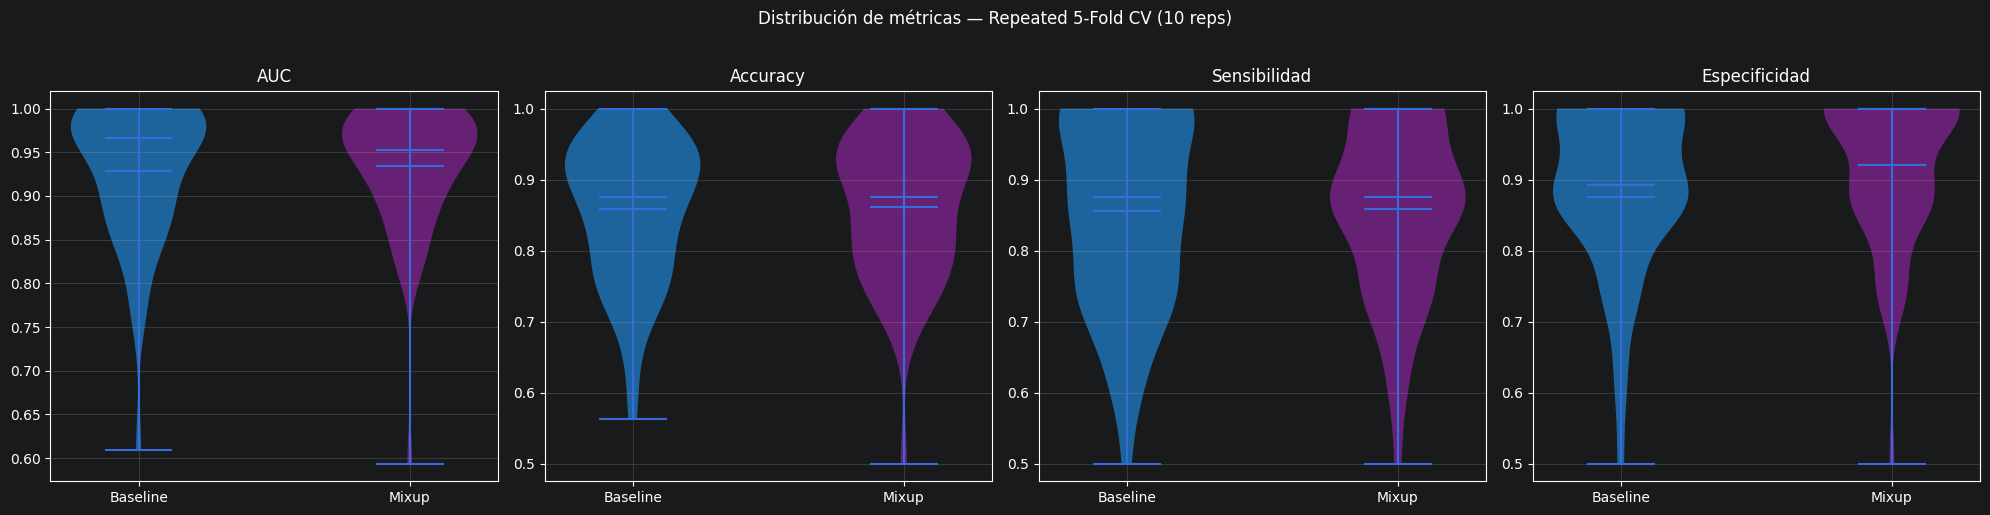

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ["auc", "acc", "sens", "spec"]
names = ["AUC", "Accuracy", "Sensibilidad", "Especificidad"]

for ax, m, name in zip(axes, metrics, names):
    data = [bl_res[m], mm_res[m]]
    parts = ax.violinplot(data, positions=[0, 1], showmeans=True, showmedians=True)
    for i, c in enumerate(["#2196F3", "#9C27B0"]):
        parts["bodies"][i].set_facecolor(c); parts["bodies"][i].set_alpha(0.6)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Baseline", "Mixup"])
    ax.set_title(name); ax.grid(alpha=0.3)

plt.suptitle(f"Distribución de métricas — Repeated {N_FOLDS}-Fold CV ({N_REPEATS} reps)", y=1.02)
plt.tight_layout(); plt.show()

## 16. Conclusiones y siguientes pasos

**Reportar como tabla final** (académico):

> Resultados HC vs PD en Neurovoz (DDK `/pa-ta-ka/`, $N=99$), Repeated 5-Fold CV con bootstrap IC 95 %.  
> Baseline: arquitectura dual-branch wav2vec2-L0 + Mel-stats sin aumento.  
> Mixup Opt: mismo modelo con Manifold Mixup intra-clase tras búsqueda Optuna de hiperparámetros.

**Posibles extensiones** (heredadas del notebook PATAKA original):

1. **Comparación de encoders** — HuBERT, WavLM, XLS-R para evaluar si un mejor *upstream* eleva el techo.
2. **Gaussian Noise augmentation** — alternativa basada en SNR (perturbación en señal vs. en embedding).
3. **Directional Mixup** — interpolar a lo largo del PC1 intra-clase + componente inter-clase con *soft labels*.
4. **Test cross-corpora** — entrenar en Neurovoz, evaluar en PC-GITA o italiano (Dimauro). Medirá la transferibilidad lingüística del biomarcador.
5. **Speaker-disjoint en múltiples grabaciones** — si se incluyen también vocales (`A1`, `E1`, ...), agrupar por `subject_id` con `GroupKFold` para evitar fuga.

**Referencias clave**

- Mendes-Laureano *et al.* (2024), *NeuroVoz: a Castillian Spanish corpus of parkinsonian speech*. arXiv:2403.02371.
- Baevski *et al.* (2020), *wav2vec 2.0*. NeurIPS.
- Verma *et al.* (2019), *Manifold Mixup*. ICML.
- Akiba *et al.* (2019), *Optuna*. KDD.
- Efron (1979), *Bootstrap Methods*. Annals of Statistics.